# Chapter 168 — Projection Matrices

> **Prerequisites:** Dot product *(ch131)*, transpose *(ch155)*, matrix inverse *(ch157)*
> **You will learn:**
> - Orthogonal projection onto a subspace
> - The projection matrix formula P = A(AᵀA)⁻¹Aᵀ
> - Why P² = P and Pᵀ = P (idempotent, symmetric)
> - Least squares as projection onto the column space
>
> **Environment:** Python 3.x, numpy, matplotlib

Projection onto line spanned by [2,1]:
  b = [3. 4.]
  Pb (projection) = [4. 2.]
  b - Pb (error)  = [-1.  2.]
  Orthogonal (dot product ≈ 0): True
  P² = P (idempotent): True
  Pᵀ = P (symmetric):  True


C:\Users\user\AppData\Local\Temp\ipykernel_14324\1792888106.py:51: UserWarning: Glyph 8869 (\N{UP TACK}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8869 (\N{UP TACK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


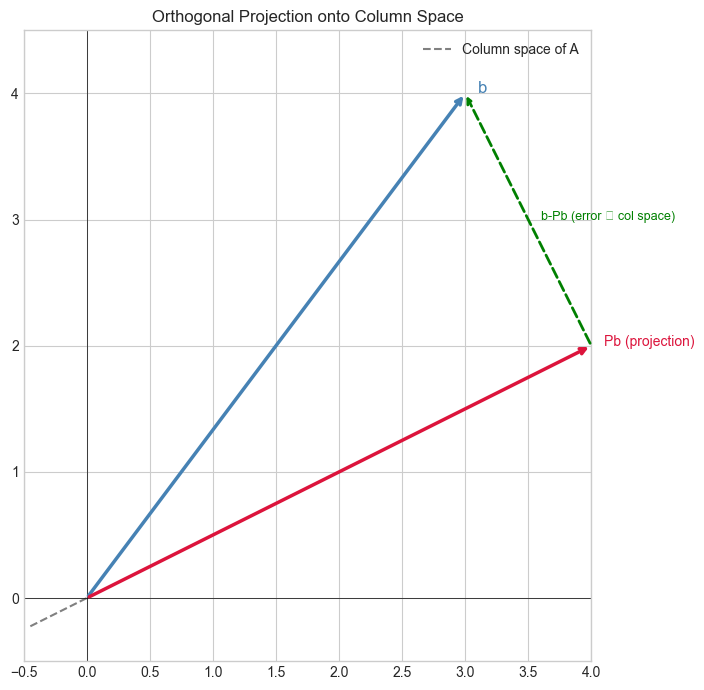

In [1]:
# --- Projection Matrices ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def projection_matrix(A):
    """
    Compute the orthogonal projection matrix onto the column space of A.
    P = A(AᵀA)⁻¹Aᵀ

    Args:
        A: 2D array (m, n), assumed full column rank (n ≤ m)

    Returns:
        P: (m, m) symmetric idempotent projection matrix
    """
    ATA = A.T @ A
    # Use solve for numerical stability instead of explicit inverse
    ATA_inv_AT = np.linalg.solve(ATA, A.T)   # = (AᵀA)⁻¹Aᵀ
    return A @ ATA_inv_AT

# Project onto a line (1D column space)
a = np.array([[2.], [1.]])   # direction to project onto
P_line = projection_matrix(a)
b = np.array([3., 4.])
b_proj = P_line @ b
b_perp = b - b_proj

print("Projection onto line spanned by [2,1]:")
print(f"  b = {b}")
print(f"  Pb (projection) = {b_proj.round(4)}")
print(f"  b - Pb (error)  = {b_perp.round(4)}")
print(f"  Orthogonal (dot product ≈ 0): {abs(np.dot(b_proj, b_perp)) < 1e-10}")
print(f"  P² = P (idempotent): {np.allclose(P_line @ P_line, P_line)}")
print(f"  Pᵀ = P (symmetric):  {np.allclose(P_line.T, P_line)}")

# Visualize projection in 2D
fig, ax = plt.subplots(figsize=(7,7))
ax.annotate('', xy=b, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.text(b[0]+0.1, b[1], 'b', fontsize=12, color='steelblue')
ax.annotate('', xy=b_proj, xytext=(0,0), arrowprops=dict(arrowstyle='->', color='crimson', lw=2.5))
ax.text(b_proj[0]+0.1, b_proj[1], 'Pb (projection)', fontsize=10, color='crimson')
ax.annotate('', xy=b, xytext=b_proj, arrowprops=dict(arrowstyle='->', color='green', lw=2, linestyle='dashed'))
ax.text((b[0]+b_proj[0])/2+0.1, (b[1]+b_proj[1])/2, 'b-Pb (error ⊥ col space)', fontsize=9, color='green')
# Show the line direction
t = np.linspace(-0.5, 2.5, 2); line_dir = a.flatten()/np.linalg.norm(a)
ax.plot(t*line_dir[0], t*line_dir[1], 'gray', lw=1.5, linestyle='--', label='Column space of A')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4.5); ax.set_aspect('equal')
ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
ax.legend(); ax.set_title('Orthogonal Projection onto Column Space')
plt.tight_layout(); plt.show()

Residual ||b - Pb||: 3.9311
Residual ⊥ col(A): True
Fitted: slope=1.9748, intercept=0.9564


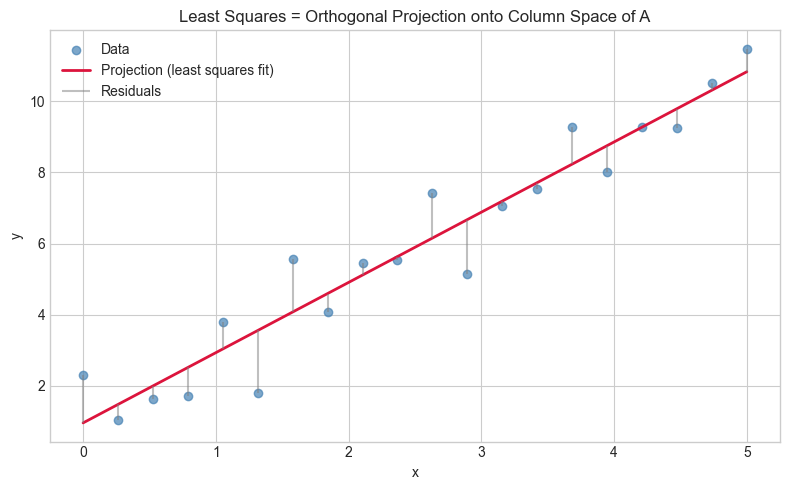

In [2]:
# --- Least squares as projection ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(1)
# Overdetermined system: 20 equations, 2 unknowns
x_data = np.linspace(0, 5, 20)
A = np.column_stack([x_data, np.ones(20)])  # (20, 2)
b = 2*x_data + 1 + 0.8*np.random.randn(20)  # noisy data

# Projection gives least-squares solution
P = projection_matrix(A)
b_hat = P @ b            # projection of b onto column space of A (the 'best fit' vector)
x_star = np.linalg.solve(A.T @ A, A.T @ b)  # coefficients

residual = b - b_hat
print(f"Residual ||b - Pb||: {np.linalg.norm(residual):.4f}")
print(f"Residual ⊥ col(A): {np.allclose(A.T @ residual, 0, atol=1e-10)}")
print(f"Fitted: slope={x_star[0]:.4f}, intercept={x_star[1]:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(x_data, b, color='steelblue', alpha=0.7, label='Data')
plt.plot(x_data, A @ x_star, 'crimson', lw=2, label='Projection (least squares fit)')
plt.vlines(x_data, b, A @ x_star, colors='gray', alpha=0.5, label='Residuals')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Least Squares = Orthogonal Projection onto Column Space of A')
plt.legend(); plt.tight_layout(); plt.show()

---

## 4. Mathematical Formulation

```
Orthogonal projection onto col(A):
  P = A(AᵀA)⁻¹Aᵀ    — for A with full column rank

Properties (defining a projection):
  P² = P             idempotent: projecting twice = projecting once
  Pᵀ = P             symmetric: orthogonal projection
  (I-P)P = 0         I-P projects onto the orthogonal complement

Least squares: min ||Ax - b||²
  Solution: x* = (AᵀA)⁻¹Aᵀb = A⁺b  (when full column rank)
  Geometric meaning: Ax* = Pb = projection of b onto col(A)
  Residual b - Pb is perpendicular to every column of A
```

---

## 7. Exercises

**Easy 1.** Verify that for the projection matrix P: `P² = P` and `Pᵀ = P`. What are the eigenvalues of a projection matrix? (Hint: Pv = v or Pv = 0)

**Easy 2.** What is the projection matrix onto the entire space ℝⁿ? What is the projection onto {0}?

**Medium 1.** Implement `project_onto_vector(b, a)` that projects b onto the direction a. Verify it matches `projection_matrix(a.reshape(-1,1)) @ b`.

**Medium 2.** Use projection matrices to implement an orthogonalization step: given two vectors u, v, compute the component of v orthogonal to u.

**Hard.** Show that for any matrix A with full column rank, the eigenvalues of P=A(AᵀA)⁻¹Aᵀ are all 0 or 1. Verify numerically for 5 random matrices and explain why geometrically.

---

## 9. Chapter Summary & Connections

- Projection matrix `P = A(AᵀA)⁻¹Aᵀ`. Idempotent (P²=P), symmetric (Pᵀ=P).
- Least squares solution projects b onto col(A) — the residual is perpendicular to col(A).
- `I-P` projects onto the orthogonal complement — together they decompose any vector.

**Forward connections:**
- In ch174 (PCA Intuition), PCA uses projection onto the dominant eigenvector subspace.
- In ch176 (Matrix Calculus), the gradient ∇||Ax-b||² = 2Aᵀ(Ax-b) follows from this projection geometry.